In [50]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly
import scipy.stats as scs
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.api as smt

In [51]:
#실현변동성 함수
def realized_volatility(x):
    return np.sqrt((x**2).sum())

#특이값 탐지 함수
def identify_outliers(row, n_sigmas=3):
    x = row['simple_rtn']
    mu = row['mean']
    sigma = row['std']

    if (x > mu + n_sigmas * sigma) or (x < mu - n_sigmas * sigma):
        return 1
    else:
        return 0

In [52]:
#현재 디렉토리 경로
dirNm = "dailyStock"
vspwd = os.getcwd()

#디렉토리 재설정
os.chdir(vspwd)

In [53]:
target="^GSPC" #S&P500 지수
file_path = f"{dirNm}/{target}.csv"

targetDf =  pd.read_csv(file_path, encoding="utf-8")
targetDf['Date'] = pd.to_datetime(targetDf['Date'])
targetDf = targetDf.set_index("Date")

targetDf['simple_rtn']=targetDf.adj_close.pct_change()                 #단순 수익률
targetDf['log_rtn']=np.log(targetDf.adj_close/targetDf.adj_close.shift(1))   #로그 수익률

#### 실현변동 계산

C:\Users\ckddn\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


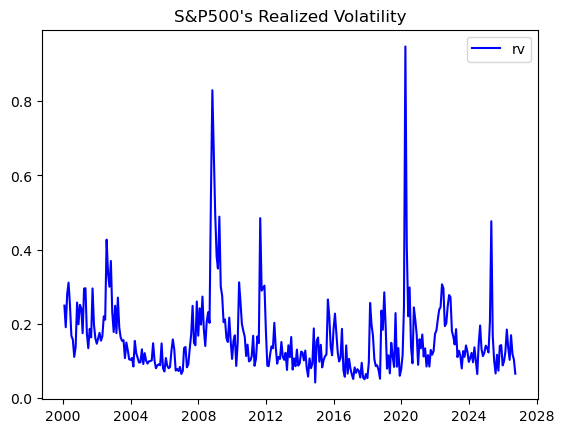

In [44]:
df_rv= targetDf.groupby(pd.Grouper(freq='ME')).apply(realized_volatility)
df_rv.rename (columns={'log_rtn':'rv'}, inplace=True)

df_rv.rv = df_rv.rv * np.sqrt(12)

fig, ax = plt.subplots()

ax.plot(df_rv.index, df_rv.rv, color='blue', label='rv')
ax.set_title("S&P500's Realized Volatility")
ax.legend(loc='upper right')

#### 특이값 식별

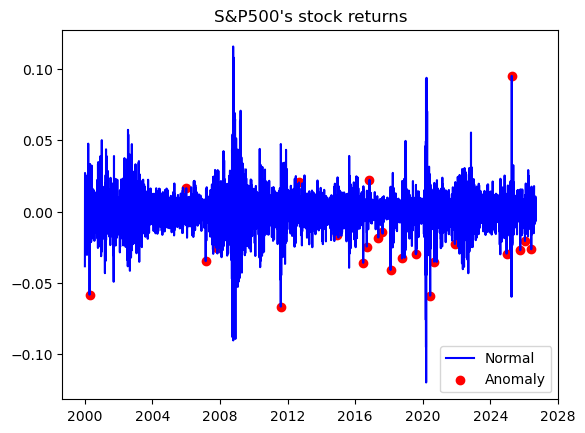

In [45]:
# 1.롤링 평균, 표준편차계산
df_rolling=targetDf[['simple_rtn']].rolling(window=21).agg(['mean', 'std'])
df_rolling.columns = df_rolling.columns.droplevel()

# 2.롱링 척도 join
df_outliers = targetDf.join(df_rolling)

# 3. 이상값 여부 체크
df_outliers['outlier'] = df_outliers.apply(identify_outliers,axis=1)

# 4. 이상값만 추출
outliers = df_outliers.loc[df_outliers['outlier'] == 1,['simple_rtn']]

fig, ax = plt.subplots()

ax.plot(df_outliers.index, df_outliers.simple_rtn, color='blue', label='Normal')
ax.scatter(outliers.index, outliers.simple_rtn, color='red', label='Anomaly')
ax.set_title("S&P500's stock returns")
ax.legend(loc='lower right')

#### 주가 시계열 시각화

[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Log returns ($)')]

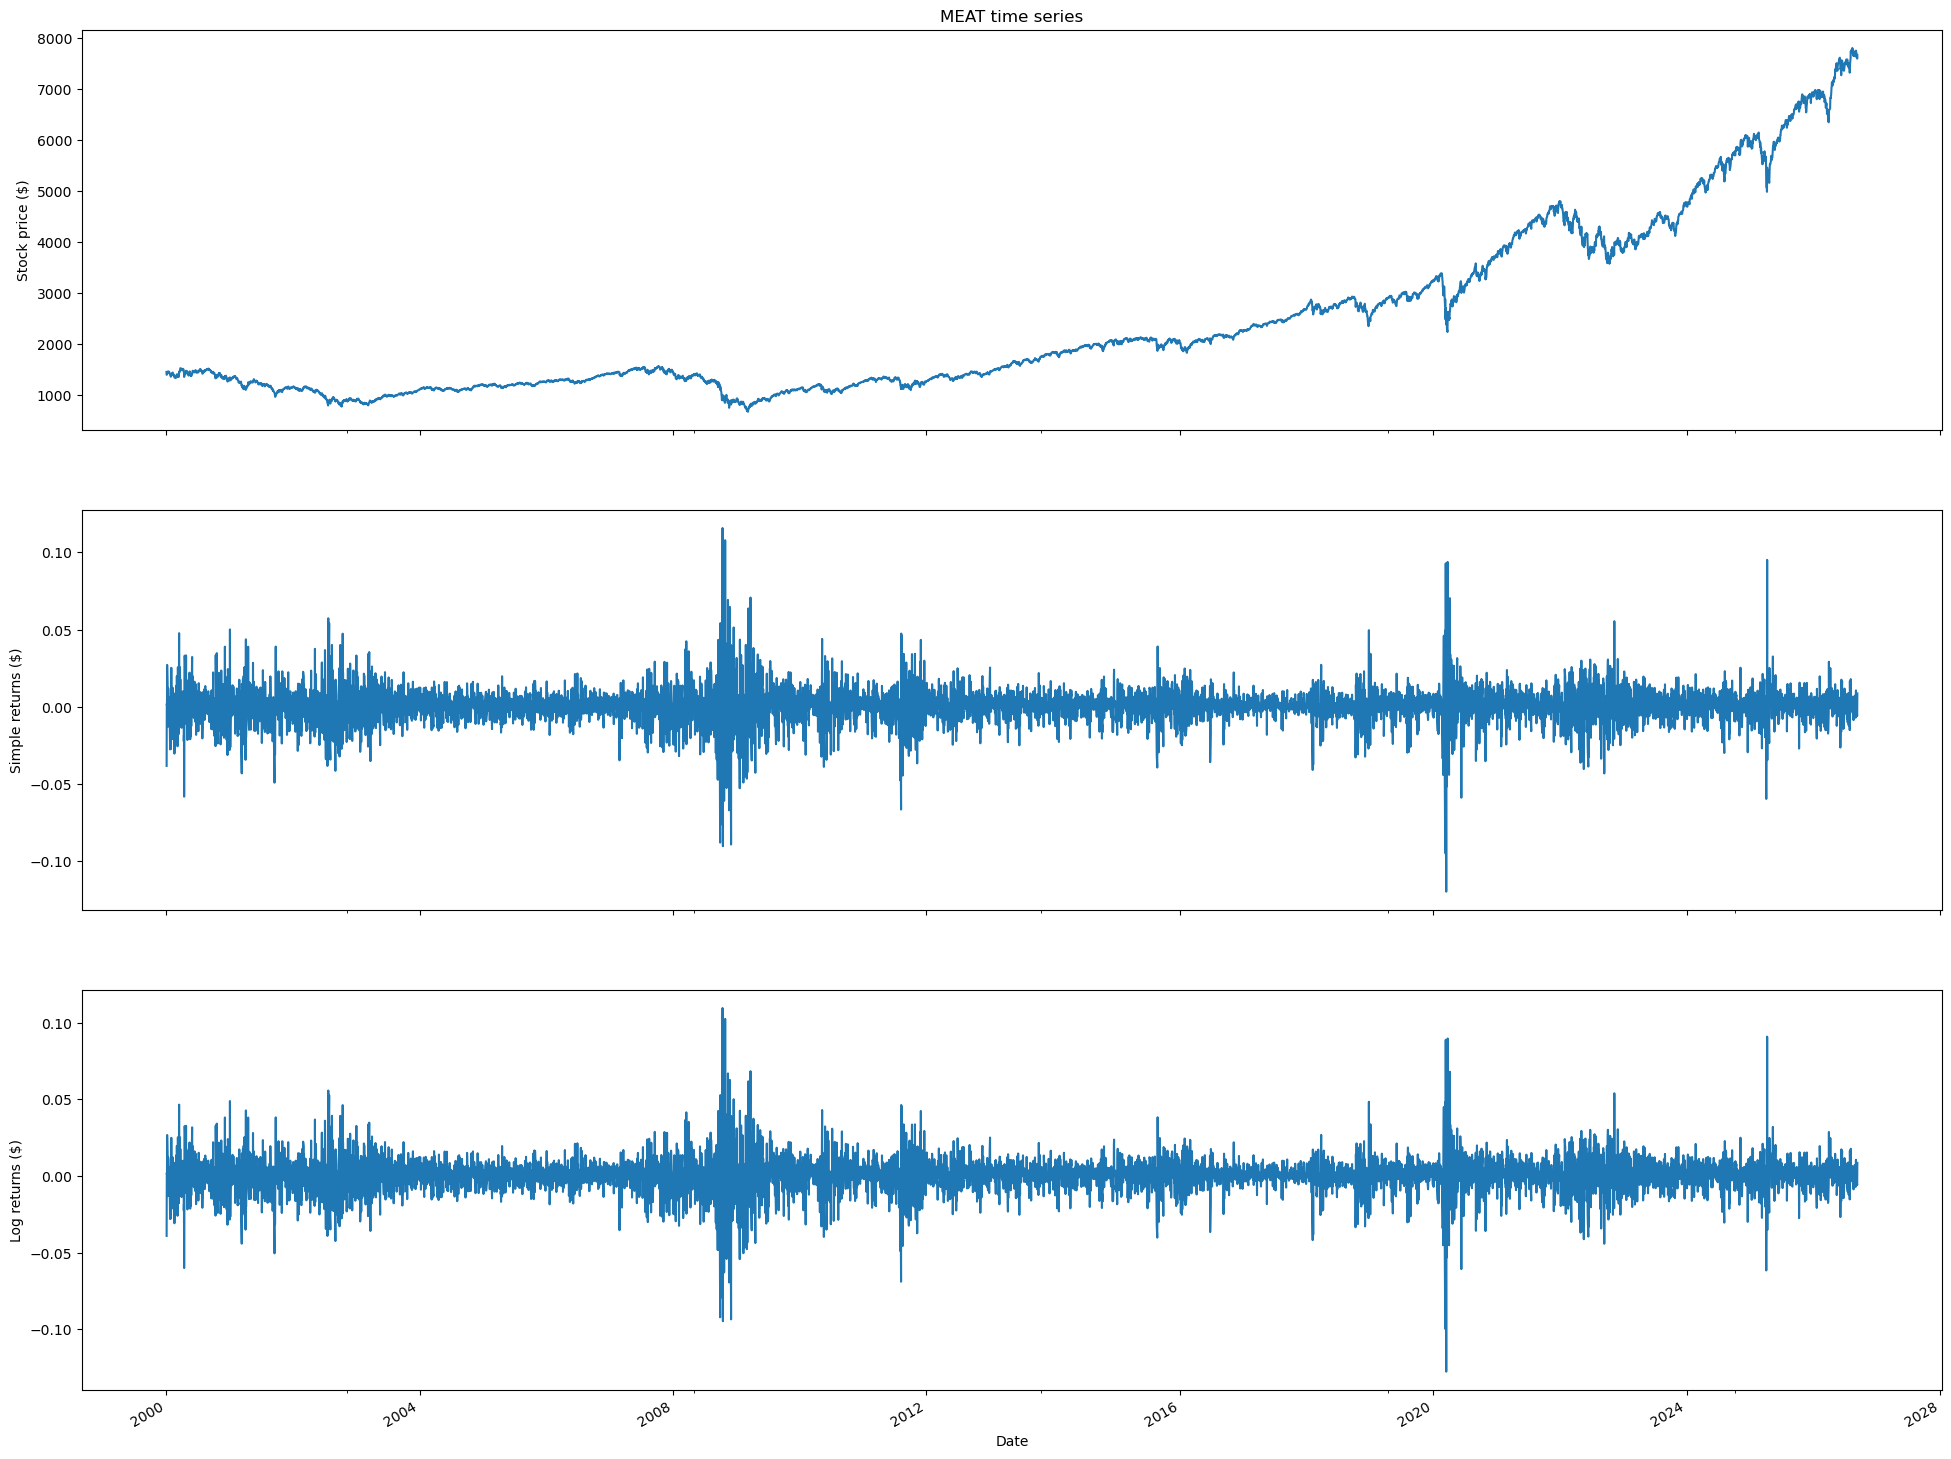

In [19]:
fig, ax = plt.subplots(3,1, figsize=(24, 20),sharex=True)

#조정 주가 시계열
targetDf.adj_close.plot(ax=ax[0])
ax[0].set(title='MEAT time series', ylabel= 'Stock price ($)')

#단순 수익률 시계열
targetDf.simple_rtn.plot(ax=ax[1])
ax[1].set(ylabel= 'Simple returns ($)')

#로그 수익률 시계열
targetDf.log_rtn.plot(ax=ax[2])
ax[2].set(xlabel='Date', ylabel= 'Log returns ($)')

#### 정규 분포 확률 밀도 함수(히스토그램, Q-Q플롯)

In [22]:
r_range = np.linspace(targetDf['log_rtn'].min(), targetDf['log_rtn'].max(),num=1000)
mu = targetDf.log_rtn.mean()
sigma = targetDf.log_rtn.std()
norm_pdf = scs.norm.pdf(r_range, loc=mu, scale=sigma)

Text(0.5, 1.0, 'Q-Q Plot')

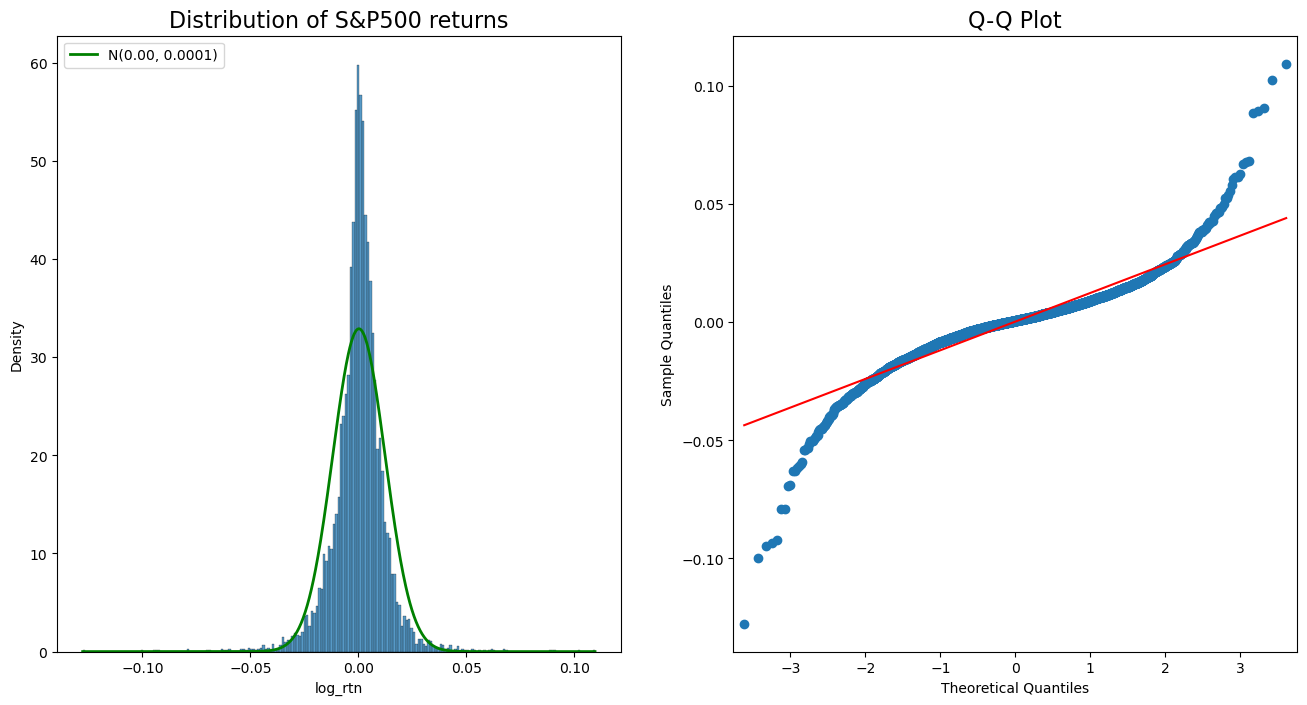

In [25]:
fig, ax = plt.subplots(1,2, figsize=(16,8))

#히스토그램
sns.histplot(targetDf.log_rtn, kde=False, stat='density', ax=ax[0])

ax[0].set_title("Distribution of S&P500 returns", fontsize=16)
ax[0].plot(r_range, norm_pdf, 'g', lw=2, label=f'N({mu:.2f}, {sigma**2:.4f})')
ax[0].legend(loc="upper left")

#Q-Q플롯
qq= sm.qqplot(targetDf['log_rtn'].dropna(), line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot', fontsize=16)

#### 요약 통계량

In [27]:
jb_test = scs.jarque_bera(targetDf.log_rtn.dropna())

print('---------- Descriptive Statistics ----------')
print('Range of dates:', min(targetDf.index.date), '-', max(targetDf.index.date))
print('Number of observations:', targetDf.shape[0])
print(f'Mean: {targetDf.log_rtn.mean():.4f}')
print(f'Median: {targetDf.log_rtn.median():.4f}')
print(f'Min: {targetDf.log_rtn.min():.4f}')
print(f'Max: {targetDf.log_rtn.max():.4f}')
print(f'Standard Deviation: {targetDf.log_rtn.std():.4f}')
print(f'Skewness: {targetDf.log_rtn.skew():.4f}')
print(f'Kurtosis: {targetDf.log_rtn.kurtosis():.4f}') 
print(f'Jarque-Bera statistic: {jb_test[0]:.2f} with p-value: {jb_test[1]:.2f}')

---------- Descriptive Statistics ----------
Range of dates: 2000-01-03 - 2026-09-11
Number of observations: 6713
Mean: 0.0002
Median: 0.0006
Min: -0.1277
Max: 0.1096
Standard Deviation: 0.0121
Skewness: -0.3486
Kurtosis: 10.6762
Jarque-Bera statistic: 31959.87 with p-value: 0.00


#### 변동성 클러스터링

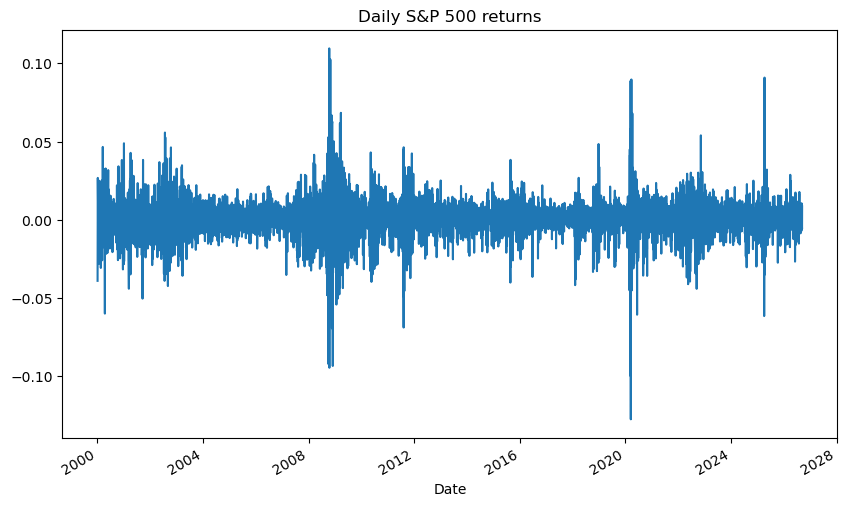

In [28]:
targetDf.log_rtn.plot(title='Daily S&P 500 returns', figsize=(10, 6))
plt.show()

#### 자기상관

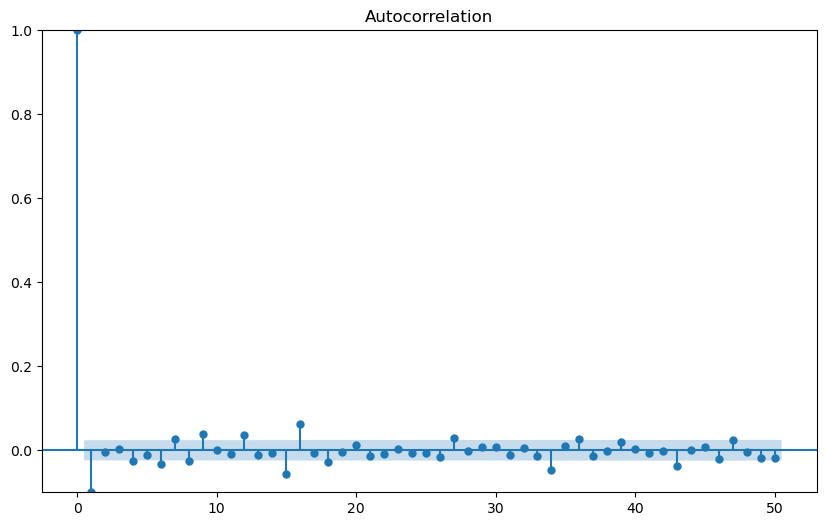

In [34]:
N_LAGS = 50
SIGNIFICANCE_LEVEL = 0.05

fig, ax = plt.subplots(figsize=(10, 6))

smt.graphics.plot_acf(
    targetDf['log_rtn'].dropna(),
    lags=N_LAGS,
    alpha=SIGNIFICANCE_LEVEL,
    ax=ax
)
ax.set_ylim(-0.1, 1)

plt.show()

#### ACF도면

(-0.1, 1.0)

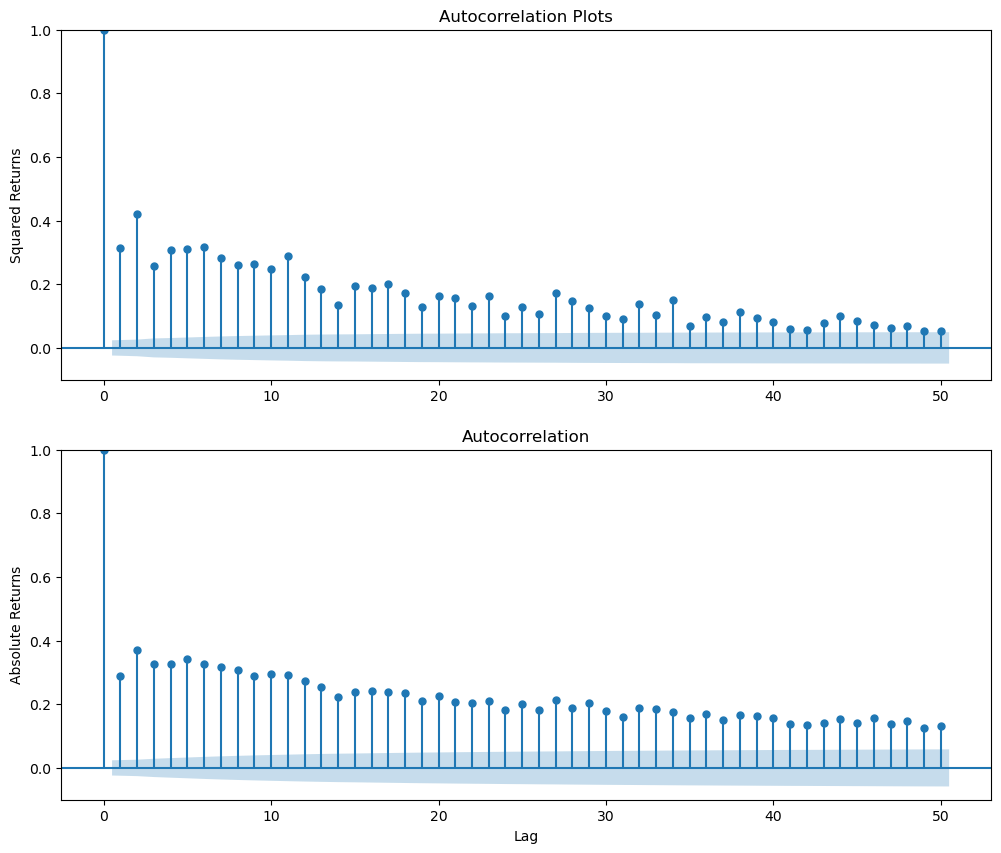

In [36]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

smt.graphics.plot_acf(targetDf['log_rtn'].dropna() ** 2, lags=N_LAGS, 
                      alpha=SIGNIFICANCE_LEVEL, ax = ax[0])
ax[0].set(title='Autocorrelation Plots',
          ylabel='Squared Returns')

ax[0].set_ylim(-0.1, 1)

smt.graphics.plot_acf(np.abs(targetDf['log_rtn'].dropna()), lags=N_LAGS, 
                      alpha=SIGNIFICANCE_LEVEL, ax = ax[1])
ax[1].set(ylabel='Absolute Returns',
          xlabel='Lag')

ax[1].set_ylim(-0.1, 1)

#### 레버리지 효과

In [48]:
targetDf['moving_std_252'] = targetDf[['log_rtn']].rolling(window=252).std()
targetDf['moving_std_21'] = targetDf[['log_rtn']].rolling(window=21).std()

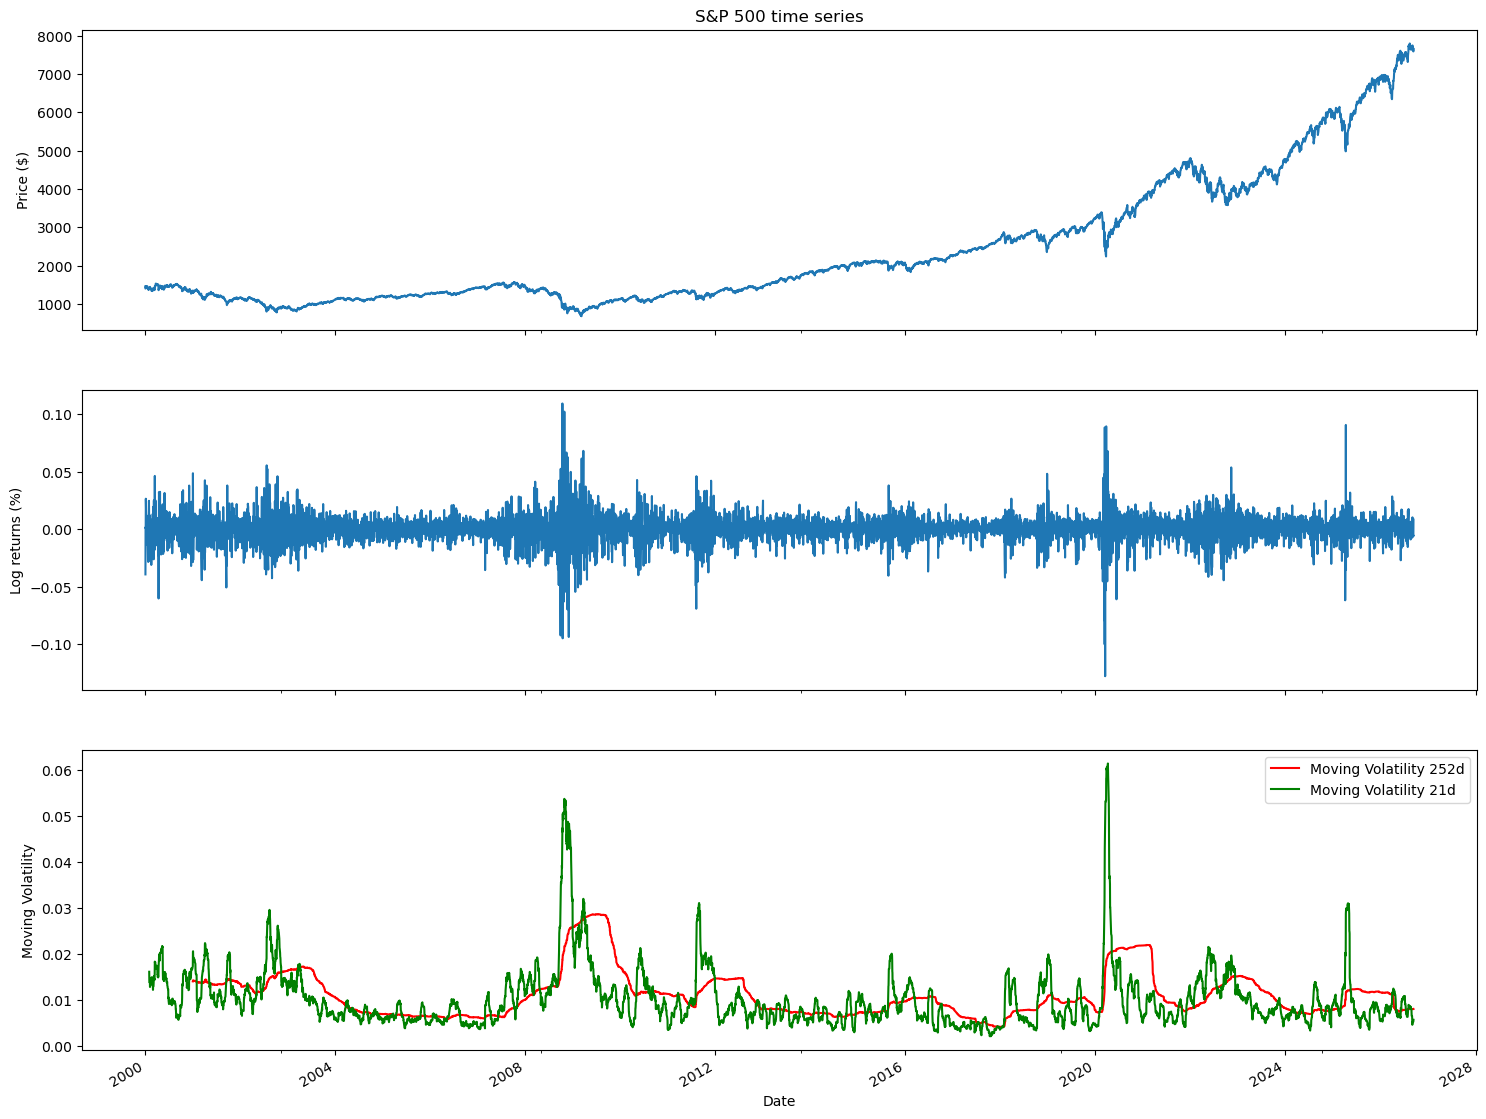

In [49]:
fig, ax = plt.subplots(3, 1, figsize=(18, 15), 
                       sharex=True)

targetDf.adj_close.plot(ax=ax[0])
ax[0].set(title='S&P 500 time series',
          ylabel='Price ($)')

targetDf.log_rtn.plot(ax=ax[1])
ax[1].set(ylabel='Log returns (%)')

targetDf.moving_std_252.plot(ax=ax[2], color='r', 
                       label='Moving Volatility 252d')
targetDf.moving_std_21.plot(ax=ax[2], color='g', 
                      label='Moving Volatility 21d')
ax[2].set(ylabel='Moving Volatility',
          xlabel='Date')
ax[2].legend()

plt.show()

In [60]:
#VIX
volDf =  pd.read_csv(f"{dirNm}/^VIX.csv", encoding="utf-8")
volDf['Date'] = pd.to_datetime(volDf['Date'])
volDf = volDf.set_index("Date")

targetDf['vol_rtn'] = np.log(volDf.adj_close/volDf.adj_close.shift(1))

            adj_close      Close       High        Low       Open  Volume  \
Date                                                                        
2000-01-03  24.209999  24.209999  26.150000  23.980000  24.360001       0   
2000-01-04  27.010000  27.010000  27.180000  24.799999  24.940001       0   
2000-01-05  26.410000  26.410000  29.000000  25.850000  27.980000       0   
2000-01-06  25.730000  25.730000  26.709999  24.700001  26.680000       0   
2000-01-07  21.719999  21.719999  25.170000  21.719999  25.139999       0   

             vol_rtn  
Date                  
2000-01-03       NaN  
2000-01-04  0.109441  
2000-01-05 -0.022464  
2000-01-06 -0.026085  
2000-01-07 -0.169424  


[Text(0.5, 1.0, 'S&P 500 vs. VIX ($\\rho$=1.00)'),
 Text(0, 0.5, 'VIX log returns'),
 Text(0.5, 0, 'S&P 500 log returns')]

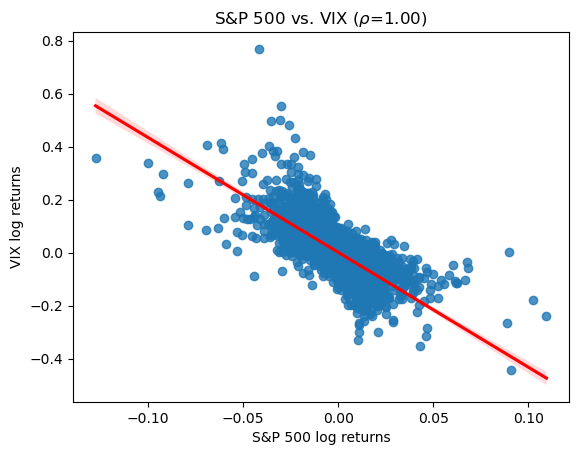

In [64]:
corr_coeff = targetDf.log_rtn.corr(targetDf['log_rtn'].dropna())

ax = sns.regplot(x='log_rtn',y='vol_rtn',data=targetDf,line_kws={'color':'red'})

ax.set(title=f'S&P 500 vs. VIX ($\\rho$={corr_coeff:.2f})',ylabel='VIX log returns', xlabel='S&P 500 log returns')